#1) LIBRARIES IMPORT

In [1]:
import pandas as pd
import numpy as np
import re
import nltk

In [2]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

#2) LOAD DATASET

In [5]:
df = pd.read_csv("Meesho.csv")

In [6]:
df.head()

,reviewId,content,score,thumbsUpCount,at,replyContent,repliedAt,appName
0,71f2dd28-b125-4baa-9318-b1ade4014d7c,"worst app i have used so far, for shopping. so...",1,337,1697744361000,"Hi, thank you so much for bringing this issue ...",1.697746e+12,Meesho
1,456f060f-055d-42ec-af81-5cd986ccc6cd,"Hi meesho, I was unable to open the app. when ...",4,0,1692755258000,"Hi, We’d just like to thank you for taking the...",1.692756e+12,Meesho
2,d1467361-fb6b-4089-b70f-1e6d11cb8c64,Worst experience with the app. Out of my 4 ord...,1,74,1634896280000,"Hello, we are sorry to learn that you had an u...",1.634742e+12,Meesho
3,e583d050-b1a8-4072-adbb-7d335e3b4072,Abstly amazing. Products at convenient prices....,5,3684,1722424087000,"Hi, We’d just like to thank you for taking the...",1.722426e+12,Meesho
4,c6143a4c-d3fd-45a5-ba75-932e006573fc,"Very good , but we order two quantity they sen...",4,123,1723334324000,"Hi, We’d just like to thank you for taking the...",1.723336e+12,Meesho


In [7]:
df.tail()

,reviewId,content,score,thumbsUpCount,at,replyContent,repliedAt,appName
35995,938b3e09-1822-4e3f-bdbc-896923a2bae9,Decent app. Fast delivery. Reasonable prices. ...,4,11,1644340636000,"Hi, We’d just like to thank you for taking the...",1.644345e+12,Meesho
35996,82d04dbf-8432-4f95-89ac-7d4dbace1dde,I love this app but why the size charts are no...,4,10,1643824305000,"Hi, We’d just like to thank you for taking the...",1.643826e+12,Meesho
35997,8a15b5d4-de14-4a57-97b9-bee4f2e1c5f8,The App is too good but can't select multiple ...,5,9,1633782013000,NaN,NaN,Meesho
35998,7eca21f5-2f48-4325-a2c4-623a1beb9aae,This is very nice Reselling app. Good quality ...,5,2,1616787795000,"Hello Entrepreneur, Thank you for appreciating...",1.616942e+12,Meesho
35999,86bd13bc-0e4e-4efb-880f-28c9ac7466dc,very low quality and duplicate products. Very ...,1,0,1699572228000,"Hi, Thanks so much for bringing this issue to ...",1.699573e+12,Meesho


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewId       36000 non-null  object 
 1   content        36000 non-null  object 
 2   score          36000 non-null  int64  
 3   thumbsUpCount  36000 non-null  int64  
 4   at             36000 non-null  int64  
 5   replyContent   34875 non-null  object 
 6   repliedAt      34875 non-null  float64
 7   appName        36000 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 2.2+ MB


#3) TEXT PREPROCESSING

In [11]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

df['clean_text'] = df['content'].apply(preprocess)

#4) VECTOR (BAG OF WORDS)

In [12]:
vectorizer = CountVectorizer(max_df=0.9, min_df=5)
X = vectorizer.fit_transform(df['clean_text'])


#5) APPLY LDA MODEL

In [13]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

In [14]:
def print_topics(model, feature_names, n_words):
    for i, topic in enumerate(model.components_):
        print(f"\nTopic {i}:")
        print([feature_names[j] for j in topic.argsort()[-n_words:]])

print_topics(lda, vectorizer.get_feature_names_out(), 10)


Topic 0:
['refund', 'customer', 'one', 'worst', 'money', 'ordered', 'meesho', 'return', 'app', 'product']

Topic 1:
['good', 'show', 'option', 'product', 'time', 'order', 'problem', 'please', 'meesho', 'app']

Topic 2:
['product', 'refund', 'care', 'call', 'meesho', 'order', 'service', 'worst', 'app', 'customer']

Topic 3:
['nice', 'also', 'best', 'shopping', 'quality', 'price', 'meesho', 'app', 'product', 'good']

Topic 4:
['date', 'delivered', 'bad', 'deliver', 'app', 'day', 'time', 'product', 'order', 'delivery']


In [17]:
topic_values = lda.transform(X)
df['Topic'] = topic_values.argmax(axis=1)
df[['content', 'Topic']].head()

,content,Topic
0,"worst app i have used so far, for shopping. so...",0
1,"Hi meesho, I was unable to open the app. when ...",1
2,Worst experience with the app. Out of my 4 ord...,0
3,Abstly amazing. Products at convenient prices....,1
4,"Very good , but we order two quantity they sen...",1


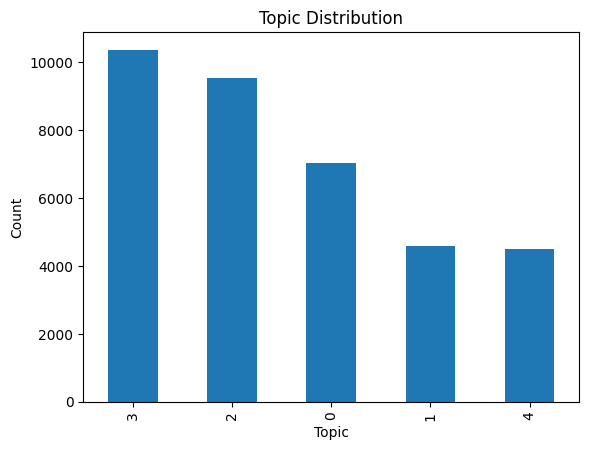

In [18]:
import matplotlib.pyplot as plt

df['Topic'].value_counts().plot(kind='bar')
plt.title("Topic Distribution")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.show()